In [1]:
from CASP16_NA_assessment import *
# global (capatalized variables) are defined in there

## investigation no contact options

In [20]:
import json
num_contacts = []
num_clashes = []
for file in glob('../raw_scores/complex/R1*o/R1*o.json'):
    with open(file, "r") as f:
        data = json.load(f)
        num_contacts.append(len(data['model_contacts']))
        num_clashes.append(len(data["model_clashes"])/len(data['local_lddt']))
print(num_contacts)

[777, 10338, 1838, 3257, 570, 1755, 1629, 1176, 2043, 1080, 10338, 4362, 604, 7062, 7539, 9188, 8904, 1457, 504, 3430, 9097, 9450, 1614, 2583, 633, 1176, 968, 1064, 964, 1964, 1331, 2758, 1293, 990, 9302, 4797, 228, 8403, 2870, 716, 1176, 1499, 960, 7539, 1283, 795, 3038, 966, 568, 1512, 2114, 1420, 8904, 9450, 1098, 1796, 3084, 14701, 695, 784, 756, 1029, 814, 1176, 8403, 773, 714, 2004, 8151, 963, 1022, 1742, 726, 773, 1176, 420, 213, 12396, 8783, 1668, 2618, 2977, 3087, 2305, 22, 3544, 1600, 84, 3530, 3112, 3114, 558, 3335, 0, 4116, 2287, 2844, 1699, 2323, 3631, 5757, 1723, 5276, 140, 955, 7, 2571, 378, 6537, 2977, 2, 6, 1141, 1665, 1355, 4312, 126, 2019, 0, 3553, 238, 2605, 1571, 135, 3331, 3530, 10, 3544, 2776, 3560, 0, 0, 2287, 914, 2633, 3560, 8636, 247, 3612, 3530, 1699, 2345, 1520, 2371, 0, 22, 16, 17, 21, 42, 55, 22, 4855, 22, 38, 32, 33, 32, 62, 23, 24, 17, 28, 24, 28, 30, 16, 58, 22, 72, 24, 21, 43, 126, 173, 32, 62, 29, 42, 24, 11, 33, 64, 116, 14, 203, 4878, 26, 947, 43, 

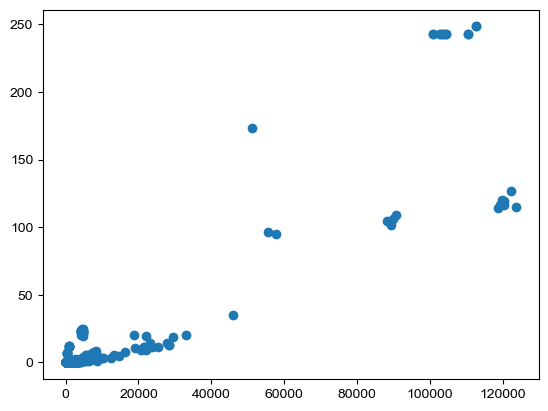

In [21]:
plt.scatter(num_contacts,num_clashes)

In [26]:
print(sum([x<8 for x in num_contacts]))
print(sum([x>10000 for x in num_contacts]))
print(len(num_contacts))

38
49
1072


(0.0, 10000.0)

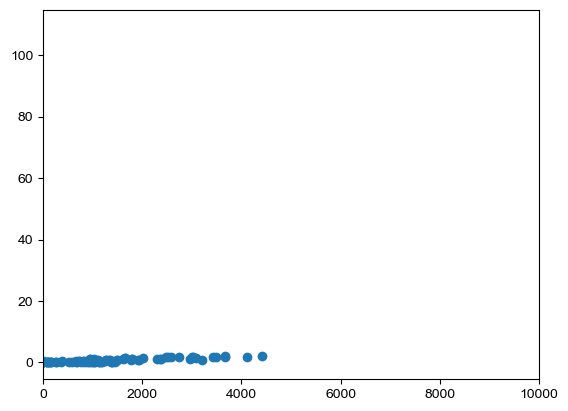

In [15]:
plt.scatter(num_contacts,num_clashes)
plt.xlim(0,10000)

# get data

In [2]:
rna_multimer_results_f = '../raw_scores/RNA_multimer_results_table.csv'

df_mutlimer = pd.read_csv(rna_multimer_results_f,
                 delim_whitespace=True,
                 usecols=range(21),
                na_values=['-'],
                index_col=False)

col_rename = {'#Model':'model','Gr.Code':'gr_code',
'RMSD':'global_rmsd','lDDT':'lddt',  
 'TMscore':'tm_score','GDT_TS':'gdt_ts',  
'MDL.Clash':'clashes_number','TMalign':'TM_align'}
df_mutlimer.rename(columns=col_rename,inplace=True)
df_mutlimer['target'] = df_mutlimer.model.apply(lambda x: x.split('TS')[0])
df_mutlimer=df_mutlimer.astype({z:float for z in MULTIMER_METRICS.keys()})
df_mutlimer['gr_code'] = df_mutlimer.gr_code.apply(lambda x: x[:-1] if 's' in x else x)

df_mutlimer['gr_code_'] = df_mutlimer.gr_code.copy()
df_mutlimer['gr_code'] = df_mutlimer.gr_code.apply(lambda x: GR_CODE_TO_NAME_SERVER[x] if x in GR_CODE_TO_NAME_SERVER else x)
print(df_mutlimer.dtypes)
print(df_mutlimer.target.unique())
print(len(df_mutlimer))
# save for comapring model names for SH
# df_mutlimer['model'].to_csv('../raw_scores/temp_multimer_model_only.csv')

df_mutlimer.head()

model              object
gr_code            object
ICS(F1)           float64
Prec.Iface        float64
Recal.Iface       float64
IPS               float64
QSglob            float64
QSbest            float64
lddt              float64
ilDDT             float64
gdt_ts            float64
global_rmsd       float64
tm_score          float64
TM_align          float64
GlobDockQ         float64
BestDockQ         float64
Mol.Size            int64
Stoich.            object
MDL.Conts           int64
REF.Conts           int64
clashes_number    float64
target             object
gr_code_           object
dtype: object
['R0250' 'R0251' 'R0252' 'R0253' 'R0254' 'R0281' 'R0283' 'R0285' 'R0290'
 'R1250' 'R1251' 'R1252' 'R1253v1' 'R1253v2' 'R1254' 'R1281' 'R1283v2'
 'R1283v3' 'R1285' 'R1290']
1460


C:\Users\racha\AppData\Local\Temp\ipykernel_18672\3846926420.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_mutlimer = pd.read_csv(rna_multimer_results_f,


,model,gr_code,ICS(F1),Prec.Iface,Recal.Iface,IPS,QSglob,QSbest,lddt,ilDDT,...,TM_align,GlobDockQ,BestDockQ,Mol.Size,Stoich.,MDL.Conts,REF.Conts,clashes_number,target,gr_code_
0,R0250TS262_4o,CoDock - 262,0.031,0.055,0.022,0.110,0.001,0.001,0.277,0.024,...,0.084,0.016,0.049,4,A4,221,366,0.0,R0250,262
1,R0250TS262_1o,CoDock - 262,0.031,0.055,0.022,0.110,0.001,0.001,0.277,0.024,...,0.084,0.016,0.049,4,A4,221,366,0.0,R0250,262
2,R0250TS262_2o,CoDock - 262,0.005,0.005,0.005,0.086,0.011,0.027,0.145,0.000,...,0.051,0.012,0.012,2,A2,577,366,2.0,R0250,262
3,R0250TS262_5o,CoDock - 262,0.005,0.005,0.005,0.086,0.011,0.027,0.145,0.000,...,0.051,0.012,0.012,2,A2,577,366,2.0,R0250,262
4,R0250TS304_4o,AF3-server - S 304,0.000,0.000,0.000,0.079,0.000,0.000,0.000,0.000,...,0.058,0.002,0.004,3,A3,17122,366,91762.0,R0250,304


In [3]:
print(len(df_mutlimer.gr_code.unique()))
df_mutlimer.gr_code.unique()

32


array(['CoDock - 262', 'AF3-server - S 304', 'OpenComplex_Server - S 450',
       'NKRNA-s - S 028', 'Zheng - 462', 'MIEnsembles-Server - S 110',
       'Vfold - 481', 'GromihaLab - 272', 'elofsson - 241', 'LCBio - 189',
       'OpenComplex - 167', 'falcon2 - S 208', 'KiharaLab - 294',
       'CSSB_experimental - 286', 'SoutheRNA - 156',
       'GuangzhouRNA_AI - 317', 'GuangzhouRNA-meta - 417',
       'Yang-Server - S 052', 'GuangzhouRNA-human - 183',
       'Bhattacharya - 369', 'Diff - 033', '406 - 159', 'B-LAB - 231',
       '405 - 325', 'GeneSilico - 338', 'isyslab-hust - 235',
       'RNAFOLDX - 435', 'dNAfold - 448', 'dMNAfold - 143',
       'kiharalab_server - S 267', 'Huang-HUST - 091', 'RNApolis - 063'],
      dtype=object)

In [4]:
df_mutlimer.groupby('target')['ICS(F1)'].max()

target
R0250      0.031
R0251      0.062
R0252      0.038
R0253      0.116
R0254      0.007
R0281      0.105
R0283      0.095
R0285      0.444
R0290      1.000
R1250      0.011
R1251      0.038
R1252      0.071
R1253v1    0.058
R1253v2    0.173
R1254      0.007
R1281      0.113
R1283v2    0.286
R1283v3    0.206
R1285      0.444
R1290      1.000
Name: ICS(F1), dtype: float64

In [5]:
df_mutlimer.groupby('target').tm_score.max()

target
R0250      0.221
R0251      0.146
R0252      0.193
R0253      0.163
R0254      0.107
R0281      0.493
R0283      0.258
R0285      0.682
R0290      0.996
R1250      0.307
R1251      0.396
R1252      0.284
R1253v1    0.417
R1253v2    0.281
R1254      0.278
R1281      0.403
R1283v2    0.376
R1283v3    0.328
R1285      0.682
R1290      0.997
Name: tm_score, dtype: float64

# Score data

In [6]:
# reduce to one (best) score per group per target
columns = ['target', 'gr_code']
best1_df_mutlimer = reduce_df(df_mutlimer, score_to_choice_best=None,
               static_columns=columns, metric_dict=MULTIMER_METRICS,
                             participipation_cutoff=PARTICIPATION_RATE,participation_score='ilDDT',
              participation_targets=MULTIMER_TARGETS)
# on the one model per group per target, calculate Z-scores for each metric
temp_dfs = []

for target in MULTIMER_TARGETS:
    #print(target)
    target_df = best1_df_mutlimer[best1_df_mutlimer.target==target].copy()
    #print(target_df.columns)
    for metric in MULTIMER_METRICS.keys():
        #print(target_df[metric])
        #print(metric)
        if ('inf' in metric and target in ['D1273','R1286']) or (metric == 'clashscore' and target in ['R1286']):
            target_df["Z_"+metric] = 0
        else:
            target_df["Z_"+metric] = get_zscore(target_df[metric].to_numpy(copy=True),
                                            negative=(MULTIMER_METRICS[metric]=="min"),
                                            tolerance_threshold=-2,
                                           penalty_threshold=None)
    temp_dfs.append(target_df)
best1_df_mutlimer = pd.concat(temp_dfs) 

# get weighted Zs
for name,score_wieghts in MULTIMER_SCORES.items():
    best1_df_mutlimer[name] = get_weighted_sum_z(best1_df_mutlimer.copy(), score_wieghts, "Z_")

combing the following columns: ['model', 'Mol.Size', 'Stoich.', 'MDL.Conts', 'REF.Conts', 'gr_code_']
gr_code
405 - 325                     0.222222
406 - 159                     0.222222
AF3-server - S 304            0.888889
B-LAB - 231                   0.222222
Bhattacharya - 369            0.333333
CSSB_experimental - 286       1.000000
CoDock - 262                  1.000000
Diff - 033                    0.222222
GeneSilico - 338              0.333333
GromihaLab - 272              0.666667
GuangzhouRNA-human - 183      1.000000
GuangzhouRNA-meta - 417       0.888889
GuangzhouRNA_AI - 317         0.555556
Huang-HUST - 091              0.444444
KiharaLab - 294               1.000000
LCBio - 189                   0.888889
MIEnsembles-Server - S 110    1.000000
NKRNA-s - S 028               1.000000
OpenComplex - 167             0.777778
OpenComplex_Server - S 450    0.666667
RNAFOLDX - 435                0.111111
RNApolis - 063                0.111111
SoutheRNA - 156               0.

C:\Users\racha\OneDrive\Desktop\CASP16_NA\NA_CASP_assessment\analysis\CASP16_NA_assessment.py:793: RuntimeWarning: Mean of empty slice
  u = np.nanmean(arr)
C:\Users\racha\anaconda3\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2053: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\racha\OneDrive\Desktop\CASP16_NA\NA_CASP_assessment\analysis\CASP16_NA_assessment.py:793: RuntimeWarning: Mean of empty slice
  u = np.nanmean(arr)
C:\Users\racha\anaconda3\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2053: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\racha\OneDrive\Desktop\CASP16_NA\NA_CASP_assessment\analysis\CASP16_NA_assessment.py:793: RuntimeWarning: Mean of empty slice
  u = np.nanmean(arr)
C:\Users\racha\anaconda3\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2053: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = n

In [7]:
best1_df_mutlimer

,target,gr_code,lddt,tm_score,gdt_ts,TM_align,global_rmsd,clashes_number,ICS(F1),Prec.Iface,...,Z_ilDDT,Z_GlobDockQ,Z_BestDockQ,Z_interface,Z_topo,Z_monomer,Z_0.6_0.4,Z_0.5_0.5,Z_0.4_0.6,Z_0.3_0.7
82,R1250,AF3-server - S 304,0.295,0.216,0.012,0.134,92.676,3920.0,0.004,0.002,...,-0.345133,3.794602,3.811014,-0.254715,-0.010418,-0.406153,-0.345578,-0.330434,-0.315290,-0.300146
84,R1250,CSSB_experimental - 286,0.376,0.225,0.011,0.136,83.959,2.0,0.000,0.000,...,0.660684,-0.408484,-0.333223,-0.002331,-0.600583,-0.251642,-0.151918,-0.126987,-0.102056,-0.077125
85,R1250,CoDock - 262,0.422,0.198,0.012,0.122,83.269,0.0,0.000,0.000,...,0.437169,-0.591227,-0.512110,-0.194196,-0.296807,0.219463,0.053999,0.012633,-0.028733,-0.070098
86,R1250,GuangzhouRNA-human - 183,0.338,0.212,0.010,0.116,94.391,1215.0,0.000,0.000,...,-0.456891,-0.408484,-0.452481,0.068504,-1.540778,-1.054366,-0.605218,-0.492931,-0.380644,-0.268357
87,R1250,GuangzhouRNA-meta - 417,0.279,0.205,0.013,0.104,85.520,4598.0,0.001,0.000,...,-0.121618,-0.042998,-0.064891,-0.261937,0.547925,-0.171613,-0.207742,-0.216775,-0.225807,-0.234839
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299,R1290,Vfold - 481,0.889,0.993,0.864,0.993,1.462,0.0,0.889,0.833,...,1.066759,1.026063,1.026063,1.004649,1.076837,1.034602,1.022621,1.019626,1.016630,1.013635
300,R1290,Yang-Server - S 052,0.866,0.988,0.925,0.987,2.224,5.0,0.824,0.857,...,0.199287,0.389097,0.389097,0.646681,1.165554,0.971787,0.841745,0.809234,0.776723,0.744213
301,R1290,Zheng - 462,0.762,0.853,0.560,0.833,21.759,74.0,0.453,0.375,...,-0.690267,-0.509189,-0.509189,-0.132746,0.285743,-0.080827,-0.101595,-0.106786,-0.111978,-0.117170
304,R1290,elofsson - 241,0.748,0.550,0.281,0.519,28.652,58.0,0.507,0.406,...,0.470569,-0.296867,-0.296867,-0.049267,-0.809555,-0.808642,-0.504892,-0.428955,-0.353017,-0.277080


In [8]:
# Models only in RNA monomer results:
rna_multi_AK = ['R1253v1TS235_4o', 'R1253v2TS435_2o', 'R1250TS208_2o', 'R1253v2TS435_1o', 'R1253v2TS231_1o', 'R1281TS063_1o', 'R1285TS267_4o', 'R1283v3TS208_5o', 'R1253v1TS435_1o', 'R1283v3TS304_1o', 'R1253v1TS417_2o', 'R1285TS208_2o', 'R1283v3TS304_2o', 'R1253v2TS435_4o', 'R1250TS417_1o', 'R1283v2TS267_5o', 'R1250TS417_2o', 'R1283v3TS208_2o', 'R1253v2TS208_3o', 'R1283v3TS304_3o', 'R1283v3TS208_3o', 'R1283v3TS304_4o', 'R1250TS208_1o', 'R1252TS417_5o', 'R1253v1TS435_3o', 'R1253v2TS235_4o', 'R1253v2TS208_2o', 'R1253v1TS435_2o', 'R1290TS267_1o', 'R1285TS208_5o', 'R1253v1TS156_3o', 'R1252TS033_1o', 'R1281TS304_4o', 'R1290TS267_4o', 'R1252TS033_2o', 'R1252TS231_1o', 'R1253v2TS435_3o', 'R1254TS241_1o', 'R1253v1TS435_5o', 'R1290TS267_3o', 'R1285TS304_3o', 'R1253v2TS208_5o', 'R1285TS208_1o', 'R1290TS267_5o', 'R1285TS267_5o', 'R1253v1TS435_4o', 'R1283v3TS208_1o', 'R1283v3TS208_4o', 'R1285TS304_5o', 'R1283v2TS267_1o', 'R1253v2TS156_3o', 'R1281TS304_3o', 'R1253v2TS435_5o', 'R1253v1TS231_1o', 'R1283v3TS294_1o', 'R1283v3TS294_2o', 'R1283v3TS304_5o', 'R1285TS267_3o']

# Models only in base pair tables:
rna_multi_SH = ['M1221TS481_4', 'M1221TS231_3', 'M1221TS159_5', 'M1221TS241_3', 'M1224TS267_2', 'M1221TS325_4', 'M1221TS325_3', 'M1221TS304_3', 'M1221TS286_5', 'M1224TS262_4', 'M1224TS208_5', 'M1224TS231_4', 'M1224TS369_3', 'M1224TS325_5', 'M1224TS159_5', 'M1224TS033_4', 'M1221TS110_1', 'M1221TS231_1', 'M1224TS462_1', 'M1221TS167_3', 'M1224TS028_5', 'M1221TS028_3', 'M1221TS231_4', 'M1224TS231_5', 'M1221TS369_5', 'M1221TS241_1', 'M1221TS450_4', 'M1224TS286_3', 'M1221TS028_4', 'M1221TS167_5', 'M1224TS369_1', 'M1224TS231_2', 'M1224TS294_1', 'M1221TS033_4', 'M1224TS241_4', 'M1221TS159_3', 'M1224TS189_3', 'M1221TS304_4', 'M1221TS208_5', 'M1221TS110_3', 'M1221TS110_5', 'M1224TS231_1', 'M1221TS338_3', 'M1224TS241_1', 'M1224TS033_5', 'M1221TS338_4', 'M1224TS167_5', 'M1224TS286_2', 'M1221TS033_2', 'M1224TS450_2', 'M1224TS028_1', 'M1224TS481_1', 'M1221TS262_5', 'M1221TS481_1', 'M1221TS286_4', 'M1221TS338_5', 'M1224TS159_2', 'M1224TS208_3', 'M1224TS481_2', 'M1221TS338_2', 'M1221TS481_5', 'M1221TS262_3', 'M1224TS450_5', 'M1221TS338_1', 'M1221TS325_5', 'M1224TS450_1', 'M1221TS294_5', 'M1221TS267_5', 'M1224TS294_2', 'M1224TS450_4', 'M1221TS033_3', 'M1221TS159_2', 'R1254TS033_2o', 'M1224TS208_2', 'M1221TS286_3', 'M1221TS231_5', 'M1224TS294_5', 'M1224TS110_2', 'M1224TS286_4', 'M1221TS262_1', 'M1221TS462_5', 'M1224TS028_3', 'M1221TS462_4', 'M1221TS267_1', 'R1254TS033_1o', 'R1254TS033_3o', 'M1221TS241_4', 'M1224TS159_4', 'M1221TS167_2', 'M1221TS304_1', 'M1221TS369_2', 'M1224TS167_1', 'M1224TS338_2', 'M1224TS325_2', 'M1224TS272_5', 'M1221TS143_1', 'M1224TS208_4', 'M1221TS325_2', 'M1221TS110_2', 'M1224TS231_3', 'M1224TS272_3', 'M1224TS033_3', 'M1224TS159_1', 'M1221TS143_4', 'M1224TS304_4', 'M1221TS167_1', 'M1224TS462_4', 'M1224TS262_2', 'M1224TS143_4', 'M1221TS450_3', 'M1224TS272_1', 'M1224TS338_3', 'M1224TS481_3', 'M1224TS241_3', 'M1221TS241_5', 'M1221TS450_1', 'M1221TS262_2', 'M1224TS143_3', 'M1224TS110_5', 'M1221TS462_1', 'M1224TS286_5', 'M1224TS481_5', 'M1224TS267_5', 'M1224TS369_5', 'M1224TS110_4', 'M1224TS304_2', 'M1221TS208_2', 'M1224TS462_2', 'M1224TS262_1', 'M1224TS304_5', 'M1224TS267_3', 'M1221TS143_2', 'M1224TS294_3', 'M1221TS462_2', 'M1224TS167_2', 'M1224TS286_1', 'M1224TS028_2', 'M1221TS286_1', 'M1224TS208_1', 'M1224TS189_1', 'M1224TS110_1', 'M1221TS262_4', 'M1224TS369_4', 'M1221TS450_5', 'M1221TS450_2', 'M1221TS294_2', 'M1224TS167_4', 'M1221TS304_2', 'M1224TS033_1', 'M1224TS325_1', 'M1224TS338_5', 'M1224TS110_3', 'M1221TS481_2', 'M1221TS208_4', 'M1224TS272_2', 'M1221TS110_4', 'M1221TS208_3', 'M1221TS028_5', 'M1224TS369_2', 'M1221TS143_3', 'M1224TS159_3', 'M1221TS208_1', 'M1224TS028_4', 'M1221TS167_4', 'M1221TS369_4', 'M1224TS241_2', 'M1224TS272_4', 'M1224TS189_2', 'M1221TS294_1', 'M1221TS033_5', 'M1224TS267_1', 'M1221TS267_4', 'M1224TS304_3', 'M1221TS481_3', 'M1221TS462_3', 'M1221TS294_3', 'M1221TS241_2', 'M1221TS369_1', 'M1221TS294_4', 'M1221TS286_2', 'M1221TS033_1', 'M1224TS450_3', 'M1224TS262_5', 'M1224TS462_3', 'M1224TS241_5', 'M1224TS325_4', 'M1224TS294_4', 'M1224TS338_1', 'M1221TS028_1', 'M1224TS304_1', 'M1221TS231_2', 'M1224TS338_4', 'M1224TS262_3', 'M1224TS481_4', 'M1224TS143_2', 'M1224TS462_5', 'M1224TS033_2', 'M1221TS267_2', 'M1221TS028_2', 'M1224TS267_4', 'M1221TS267_3', 'M1221TS159_4', 'M1224TS167_3', 'M1224TS143_1', 'M1221TS304_5', 'M1224TS143_5']
print('missing from multimer analysis', [x for x in rna_multi_SH if 'R' in x])
# these are correctly excluded because they placed all atoms after chain 1 at the origin

missing from multimer analysis ['R1254TS033_2o', 'R1254TS033_1o', 'R1254TS033_3o']


gdt_ts
tm_score
lddt


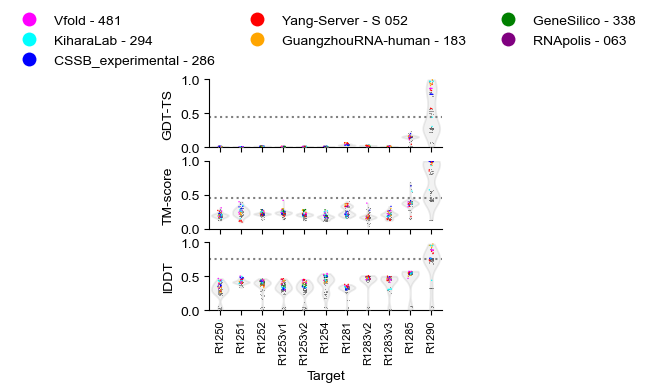

In [9]:

# if applicable
metric_pass_score = {'tm_score':0.45,
                    'gdt_ts':0.45,
                    'lddt':0.75,
                    'lddt_no_checks':0.75}

metrics_to_plot = ['gdt_ts','tm_score','lddt'] #MULTIMER_METRICS.keys()
labels = {'lddt':'lDDT','tm_score':'TM-score','gdt_ts':'GDT-TS'}

target_order = [x for x in df_mutlimer.target.unique() if 'R1' in x] # only round 1
fig,axes=plt.subplots(len(metrics_to_plot),1,figsize=(3,1*len(metrics_to_plot)),sharex=True)
for i,metric in enumerate(metrics_to_plot):
    print(metric)
    sns.violinplot(df_mutlimer,x='target',y=metric,color='grey',inner=None,ax=axes[i],alpha=0.1,density_norm='width',cut=0,order=target_order)
    g=sns.stripplot(df_mutlimer[~df_mutlimer.gr_code.isin(GROUP_HIGHLIGHTS.keys())],
                    x='target',y=metric,size=0.5, color='grey',ax=axes[i],order=target_order)
    # swarmplot
    #for g,c in group_highlights.items():
    g=sns.stripplot(df_mutlimer[df_mutlimer.gr_code.isin(GROUP_HIGHLIGHTS.keys())],
                    x='target',y=metric,size=1, hue='gr_code',palette=GROUP_HIGHLIGHTS,
                    ax=axes[i],order=target_order,legend=(i==0))

    if metric in METRIC_RANGES:
        g.set_ylim(METRIC_RANGES[metric][0],METRIC_RANGES[metric][1])
    else:
        g.set_ylim(0,1)
    xmin,xmax = g.get_xlim()
    if metric in metric_pass_score:
        g.hlines(metric_pass_score[metric],xmin,xmax,"grey",":")
    g.set_xlim(xmin,xmax)
    g.set_ylabel(labels[metric])
    g.set_xticks(g.get_xticks())
    g.set_xlabel('Target')
    g.set_xticklabels(labels=g.get_xticklabels(),rotation = 90,size=8)
    g.spines[['right', 'top']].set_visible(False)
sns.move_legend(axes[0], "lower center", bbox_to_anchor=(.5, 1), ncol=3, title=None, frameon=False,markerscale=10)
t=axes[-1].set_xticklabels(target_order,rotation=90)
plt.savefig("figure_subpanels/multimer_fold_scores.png",dpi=400, bbox_inches='tight', transparent=True)
plt.savefig("figure_subpanels/multimer_fold_scores.svg",dpi=400, bbox_inches='tight', transparent=True)


ICS(F1)
IPS
ilDDT


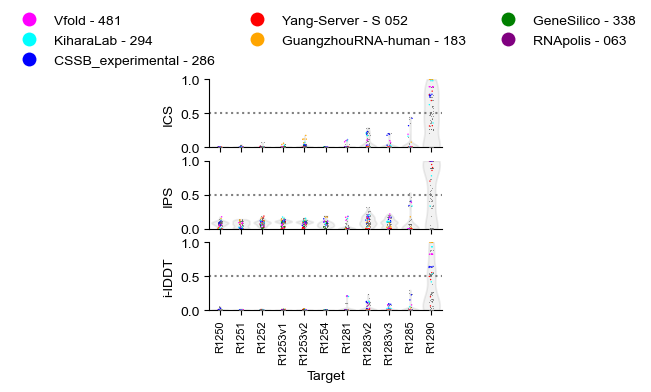

In [10]:
metrics_to_plot = ['ICS(F1)','IPS','ilDDT'] #MULTIMER_METRICS.keys()

labels = {'ilDDT':'i-lDDT','ICS(F1)':'ICS','IPS':'IPS'}

target_order = [x for x in df_mutlimer.target.unique() if 'R1' in x] # only round 1
fig,axes=plt.subplots(len(metrics_to_plot),1,figsize=(3,1*len(metrics_to_plot)),sharex=True)
for i,metric in enumerate(metrics_to_plot):
    print(metric)
    sns.violinplot(df_mutlimer,x='target',y=metric,color='grey',inner=None,ax=axes[i],alpha=0.1,density_norm='width',cut=0,order=target_order)
    g=sns.stripplot(df_mutlimer[~df_mutlimer.gr_code.isin(GROUP_HIGHLIGHTS.keys())],
                    x='target',y=metric,size=0.5, color='grey',ax=axes[i],order=target_order)
    # swarmplot
    #for g,c in group_highlights.items():
    g=sns.stripplot(df_mutlimer[df_mutlimer.gr_code.isin(GROUP_HIGHLIGHTS.keys())],
                    x='target',y=metric,size=1, hue='gr_code',palette=GROUP_HIGHLIGHTS,
                    ax=axes[i],order=target_order,legend=(i==0))

    if metric in METRIC_RANGES:
        g.set_ylim(METRIC_RANGES[metric][0],METRIC_RANGES[metric][1])
    else:
        g.set_ylim(0,1)
    xmin,xmax = g.get_xlim()
    if metric in METRIC_PASS_SCORE:
        g.hlines(METRIC_PASS_SCORE[metric],xmin,xmax,"grey",":")
    g.set_xlim(xmin,xmax)
    g.set_ylabel(labels[metric])
    g.set_xticks(g.get_xticks())
    g.set_xlabel('Target')
    g.set_xticklabels(labels=g.get_xticklabels(),rotation = 90,size=8)
    g.spines[['right', 'top']].set_visible(False)
sns.move_legend(axes[0], "lower center", bbox_to_anchor=(.5, 1), ncol=3, title=None, frameon=False,markerscale=10)
t=axes[-1].set_xticklabels(target_order,rotation=90)
plt.savefig("figure_subpanels/multimer_interface_scores.svg",dpi=400, bbox_inches='tight', transparent=True)
plt.savefig("figure_subpanels/multimer_interface_scores.png",dpi=400, bbox_inches='tight', transparent=True)


In [11]:
best1_df_mutlimer.columns

Index(['target', 'gr_code', 'lddt', 'tm_score', 'gdt_ts', 'TM_align',
       'global_rmsd', 'clashes_number', 'ICS(F1)', 'Prec.Iface', 'Recal.Iface',
       'IPS', 'QSglob', 'QSbest', 'ilDDT', 'GlobDockQ', 'BestDockQ', 'Z_lddt',
       'Z_tm_score', 'Z_gdt_ts', 'Z_TM_align', 'Z_global_rmsd',
       'Z_clashes_number', 'Z_ICS(F1)', 'Z_Prec.Iface', 'Z_Recal.Iface',
       'Z_IPS', 'Z_QSglob', 'Z_QSbest', 'Z_ilDDT', 'Z_GlobDockQ',
       'Z_BestDockQ', 'Z_interface', 'Z_topo', 'Z_monomer', 'Z_0.6_0.4',
       'Z_0.5_0.5', 'Z_0.4_0.6', 'Z_0.3_0.7'],
      dtype='object')

100%|██████████| 1000/1000 [00:16<00:00, 60.22it/s]
C:\Users\racha\OneDrive\Desktop\CASP16_NA\NA_CASP_assessment\analysis\CASP16_NA_assessment.py:1247: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_all = df_copy.pivot_table(index=group_col, columns=target_col, values=score,


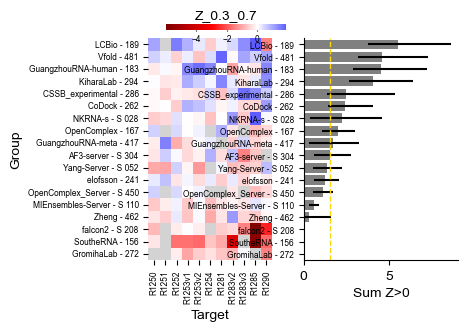

In [12]:
Z='Z_0.3_0.7'
rank,group,ci = plot_heat_map(best1_df_mutlimer,Z,savefig=f'figure_subpanels/CASP16_rna_multimer_{Z}',num_bootstrap=1000, 
                              figsize=(4,3.6),split_dims = (40,50))

In [13]:
group['lower_bound'] = ci[0]
group['upper_bound'] = ci[1]
group.to_csv('summary_tables/final_Z_NA_multimer.csv')